In [11]:
import pandas as pd

base = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/"

# ── Descarga ─────────────────────────────────────────────────────
demo = pd.read_sas(base + "P_DEMO.XPT", format="xport", encoding="utf-8")
body = pd.read_sas(base + "P_BMX.XPT",  format="xport", encoding="utf-8")
paq  = pd.read_sas(base + "P_PAQ.XPT",  format="xport", encoding="utf-8")
slq  = pd.read_sas(base + "P_SLQ.XPT",  format="xport", encoding="utf-8")
bpx  = pd.read_sas(base + "P_BPXO.XPT", format="xport", encoding="utf-8")

# ── Selección de columnas ────────────────────────────────────────
demo = demo[["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3"]]
body = body[["SEQN", "BMXWT", "BMXHT", "BMXBMI", "BMXWAIST"]]
paq  = paq[["SEQN", "PAQ605", "PAQ620", "PAD615", "PAQ650", "PAD660"]]
slq  = slq[["SEQN", "SLD012", "SLD013", "SLQ050", "SLQ120"]]
bpx  = bpx[["SEQN", "BPXOPLS1"]]

# ── Deduplicar por SEQN antes del merge ─────────────────────────
demo = demo.drop_duplicates(subset="SEQN")
body = body.drop_duplicates(subset="SEQN")
paq  = paq.drop_duplicates(subset="SEQN")
slq  = slq.drop_duplicates(subset="SEQN")
bpx  = bpx.drop_duplicates(subset="SEQN")

# ── Renombrar ────────────────────────────────────────────────────
demo.columns = ["SEQN", "age", "gender", "ethnicity"]
body.columns = ["SEQN", "weight_kg", "height_cm", "bmi", "waist_cm"]
paq.columns  = ["SEQN", "vigorous_work", "moderate_work",
                "vigorous_work_min", "vigorous_rec", "vigorous_rec_min"]
slq.columns  = ["SEQN", "sleep_weekday_hrs", "sleep_weekend_hrs",
                "told_sleep_disorder", "sleep_trouble_freq"]
bpx.columns  = ["SEQN", "resting_pulse"]

# ── Merge ────────────────────────────────────────────────────────
df = demo.merge(body, on="SEQN", how="inner") \
         .merge(paq,  on="SEQN", how="inner") \
         .merge(slq,  on="SEQN", how="inner") \
         .merge(bpx,  on="SEQN", how="inner")

# ── Limpiar códigos inválidos CDC ────────────────────────────────
df = df.mask(df.isin([77, 99, 7777, 9999]))

# ── Corregir sleep_trouble_freq ──────────────────────────────────
df["sleep_trouble_freq"] = df["sleep_trouble_freq"].round().astype("Int64")

# ── Etiquetas legibles ───────────────────────────────────────────
df["gender"] = df["gender"].map({1.0: "Male", 2.0: "Female"})
df["ethnicity"] = df["ethnicity"].map({
    1.0: "Mexican American",
    2.0: "Other Hispanic",
    3.0: "Non-Hispanic White",
    4.0: "Non-Hispanic Black",
    6.0: "Non-Hispanic Asian",
    7.0: "Other/Multiracial"
})

# ── Drop SEQN ────────────────────────────────────────────────────
df = df.drop(columns=["SEQN"])

# ── Solo adultos (18+) ───────────────────────────────────────────
df = df[df["age"] >= 18].reset_index(drop=True)

# ── Vista general ───────────────────────────────────────────────
print(df.shape)
print(df.head())
print("\nNulos por columna:")
print(df.isnull().sum())
print("\n% nulos por columna:")
print((df.isnull().sum() / len(df) * 100).round(1))

display(df)

(8893, 17)
    age  gender           ethnicity  weight_kg  height_cm   bmi  waist_cm  \
0  29.0  Female  Non-Hispanic Asian       97.1      160.2  37.8     117.9   
1  49.0    Male  Non-Hispanic White       98.8      182.3  29.7     120.4   
2  36.0    Male  Non-Hispanic White       74.3      184.2  21.9      86.8   
3  68.0    Male   Other/Multiracial      103.7      185.3  30.2     109.6   
4  76.0    Male  Non-Hispanic White       83.3      177.1  26.6       NaN   

   vigorous_work  moderate_work  vigorous_work_min  vigorous_rec  \
0            2.0            2.0                NaN           1.0   
1            2.0            1.0                NaN           2.0   
2            1.0            2.0              240.0           2.0   
3            1.0            1.0              480.0           2.0   
4            2.0            2.0                NaN           2.0   

   vigorous_rec_min  sleep_weekday_hrs  sleep_weekend_hrs  \
0              60.0                7.5                8.

,age,gender,ethnicity,weight_kg,height_cm,bmi,waist_cm,vigorous_work,moderate_work,vigorous_work_min,vigorous_rec,vigorous_rec_min,sleep_weekday_hrs,sleep_weekend_hrs,told_sleep_disorder,sleep_trouble_freq,resting_pulse
0,29.0,Female,Non-Hispanic Asian,97.1,160.2,37.8,117.9,2.0,2.0,NaN,1.0,60.0,7.5,8.0,2.0,0,68.0
1,49.0,Male,Non-Hispanic White,98.8,182.3,29.7,120.4,2.0,1.0,NaN,2.0,NaN,10.0,13.0,1.0,3,73.0
2,36.0,Male,Non-Hispanic White,74.3,184.2,21.9,86.8,1.0,2.0,240.0,2.0,NaN,6.5,8.0,1.0,2,71.0
3,68.0,Male,Other/Multiracial,103.7,185.3,30.2,109.6,1.0,1.0,480.0,2.0,NaN,9.5,9.5,2.0,0,NaN
4,76.0,Male,Non-Hispanic White,83.3,177.1,26.6,NaN,2.0,2.0,NaN,2.0,NaN,7.0,8.0,1.0,3,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8888,52.0,Male,Non-Hispanic Black,94.3,178.8,29.5,99.3,1.0,2.0,360.0,1.0,120.0,6.0,6.0,2.0,1,56.0
8889,67.0,Female,Mexican American,82.8,147.8,37.9,110.0,1.0,2.0,10.0,2.0,NaN,8.0,8.0,2.0,1,70.0
8890,40.0,Male,Non-Hispanic Black,108.8,168.7,38.2,114.7,2.0,2.0,NaN,2.0,NaN,6.0,7.0,2.0,2,120.0
8891,63.0,Male,Non-Hispanic Black,79.5,176.4,25.5,97.1,1.0,2.0,10.0,2.0,NaN,8.0,9.0,2.0,2,60.0


In [12]:
# vigorous_work_min y vigorous_rec_min:
# si no hace actividad vigorosa (valor 2), los minutos son 0, no NaN
df["vigorous_work_min"] = df.apply(
    lambda r: 0 if r["vigorous_work"] == 2.0 and pd.isna(r["vigorous_work_min"])
    else r["vigorous_work_min"], axis=1
)
df["vigorous_rec_min"] = df.apply(
    lambda r: 0 if r["vigorous_rec"] == 2.0 and pd.isna(r["vigorous_rec_min"])
    else r["vigorous_rec_min"], axis=1
)

# resting_pulse y waist_cm: imputar con la mediana
df["resting_pulse"] = df["resting_pulse"].fillna(df["resting_pulse"].median())
df["waist_cm"]      = df["waist_cm"].fillna(df["waist_cm"].median())

# weight, height, bmi: son muy pocos (2%), simplemente dropear esas filas
df = df.dropna(subset=["weight_kg", "height_cm", "bmi"]).reset_index(drop=True)

print(df.shape)
print("\n% nulos después de limpieza:")
print((df.isnull().sum() / len(df) * 100).round(1))

(8689, 17)

% nulos después de limpieza:
age                    0.0
gender                 0.0
ethnicity              0.0
weight_kg              0.0
height_cm              0.0
bmi                    0.0
waist_cm               0.0
vigorous_work          0.0
moderate_work          0.0
vigorous_work_min      0.3
vigorous_rec           0.0
vigorous_rec_min       0.1
sleep_weekday_hrs      0.8
sleep_weekend_hrs      0.9
told_sleep_disorder    0.0
sleep_trouble_freq     0.0
resting_pulse          0.0
dtype: float64


In [13]:
pd.set_option('future.no_silent_downcasting', True)

df = df.dropna().reset_index(drop=True)
print(df.shape)
print(df.isnull().sum().sum(), "nulos totales")

(8562, 17)
0 nulos totales


In [14]:
print(df.shape)
print(df.head())
print("\nNulos por columna:")
print(df.isnull().sum())
print("\n% nulos por columna:")
print((df.isnull().sum() / len(df) * 100).round(1))

(8562, 17)
    age  gender           ethnicity  weight_kg  height_cm   bmi  waist_cm  \
0  29.0  Female  Non-Hispanic Asian       97.1      160.2  37.8     117.9   
1  49.0    Male  Non-Hispanic White       98.8      182.3  29.7     120.4   
2  36.0    Male  Non-Hispanic White       74.3      184.2  21.9      86.8   
3  68.0    Male   Other/Multiracial      103.7      185.3  30.2     109.6   
4  76.0    Male  Non-Hispanic White       83.3      177.1  26.6      99.1   

   vigorous_work  moderate_work  vigorous_work_min  vigorous_rec  \
0            2.0            2.0                0.0           1.0   
1            2.0            1.0                0.0           2.0   
2            1.0            2.0              240.0           2.0   
3            1.0            1.0              480.0           2.0   
4            2.0            2.0                0.0           2.0   

   vigorous_rec_min  sleep_weekday_hrs  sleep_weekend_hrs  \
0              60.0                7.5                8.

In [15]:
# Invertir las columnas sí/no para que 1=Sí tenga sentido lógico
# Actualmente: 1=Sí hace ejercicio, 2=No → convertir a 1=Sí, 0=No
for col in ["vigorous_work", "moderate_work", "vigorous_rec", "told_sleep_disorder"]:
    df[col] = df[col].map({1.0: 1, 2.0: 0})

print(df.head())

    age  gender           ethnicity  weight_kg  height_cm   bmi  waist_cm  \
0  29.0  Female  Non-Hispanic Asian       97.1      160.2  37.8     117.9   
1  49.0    Male  Non-Hispanic White       98.8      182.3  29.7     120.4   
2  36.0    Male  Non-Hispanic White       74.3      184.2  21.9      86.8   
3  68.0    Male   Other/Multiracial      103.7      185.3  30.2     109.6   
4  76.0    Male  Non-Hispanic White       83.3      177.1  26.6      99.1   

   vigorous_work  moderate_work  vigorous_work_min  vigorous_rec  \
0              0            0.0                0.0             1   
1              0            1.0                0.0             0   
2              1            0.0              240.0             0   
3              1            1.0              480.0             0   
4              0            0.0                0.0             0   

   vigorous_rec_min  sleep_weekday_hrs  sleep_weekend_hrs  \
0              60.0                7.5                8.0   
1     

vigorous_work           0
moderate_work           6
vigorous_rec            0
told_sleep_disorder     6
sleep_trouble_freq     11
dtype: int64


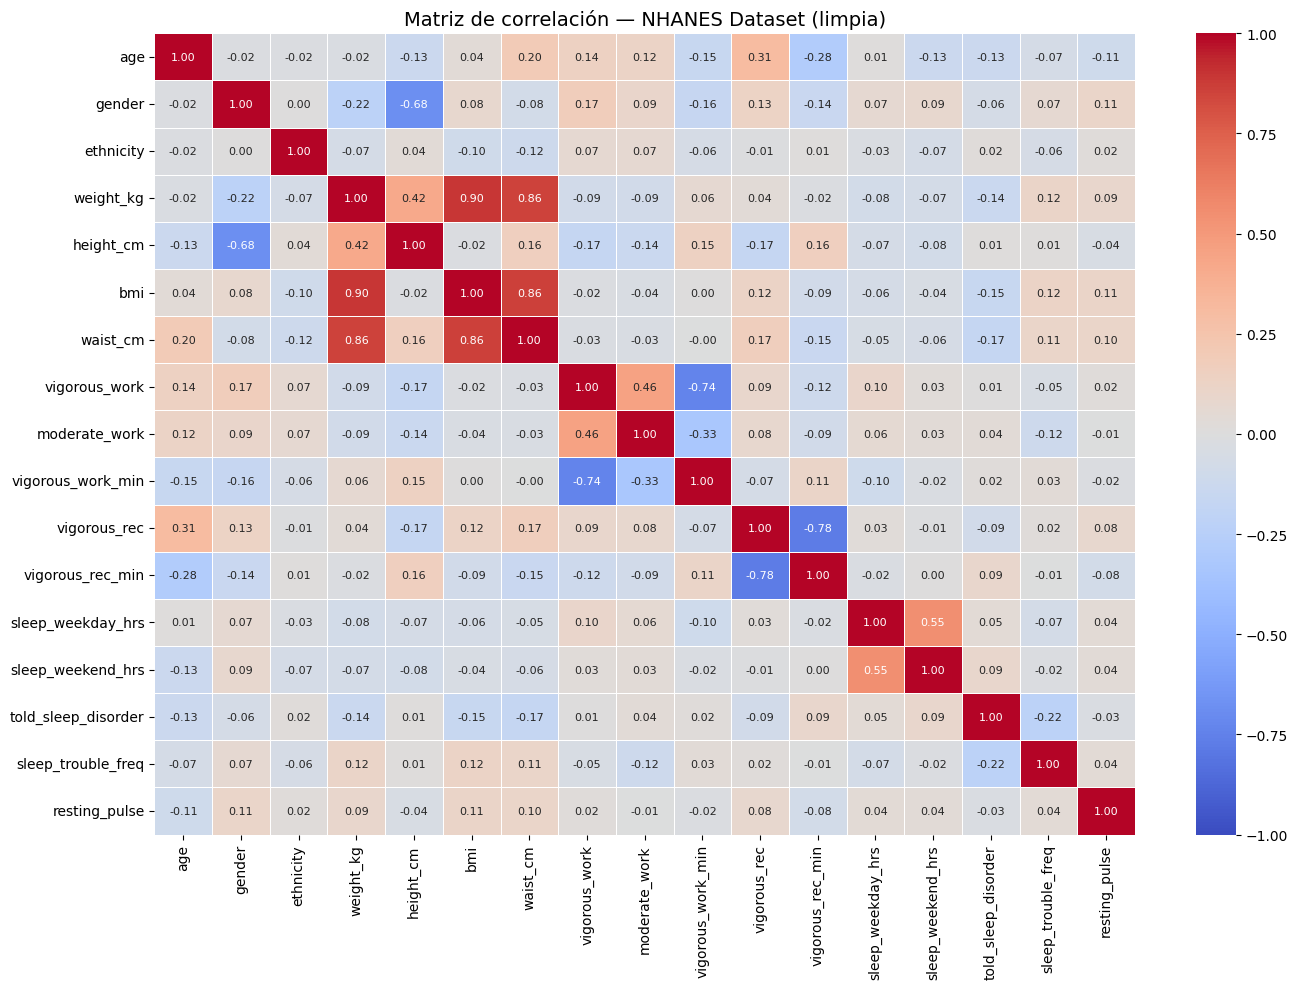

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revertir binarias a 1 y 2 original
binary_cols = ["vigorous_work", "moderate_work", "vigorous_rec", "told_sleep_disorder"]
for col in binary_cols:
    df[col] = df[col].map({1: 1.0, 0: 2.0})

# Revertir sleep_trouble_freq a escala original
df["sleep_trouble_freq"] = df["sleep_trouble_freq"].map({
    0: 0,
    1: 2,
    2: 3,
    3: 4,
    4: 5
})

print(df[binary_cols + ["sleep_trouble_freq"]].isnull().sum())

df_corr = df.copy()
df_corr["gender"] = df_corr["gender"].map({"Male": 0, "Female": 1})
df_corr["ethnicity"] = df_corr["ethnicity"].map({
    "Mexican American": 1,
    "Other Hispanic": 2,
    "Non-Hispanic White": 3,
    "Non-Hispanic Black": 4,
    "Non-Hispanic Asian": 6,
    "Other/Multiracial": 7
})

corr = df_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Matriz de correlación — NHANES Dataset (limpia)", fontsize=14)
plt.tight_layout()
plt.show()

R²:         -0.0001
RMSE:       1.7789
MAE:        1.3797
Pendiente:  0.000167
Intercepto: 8.2850


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

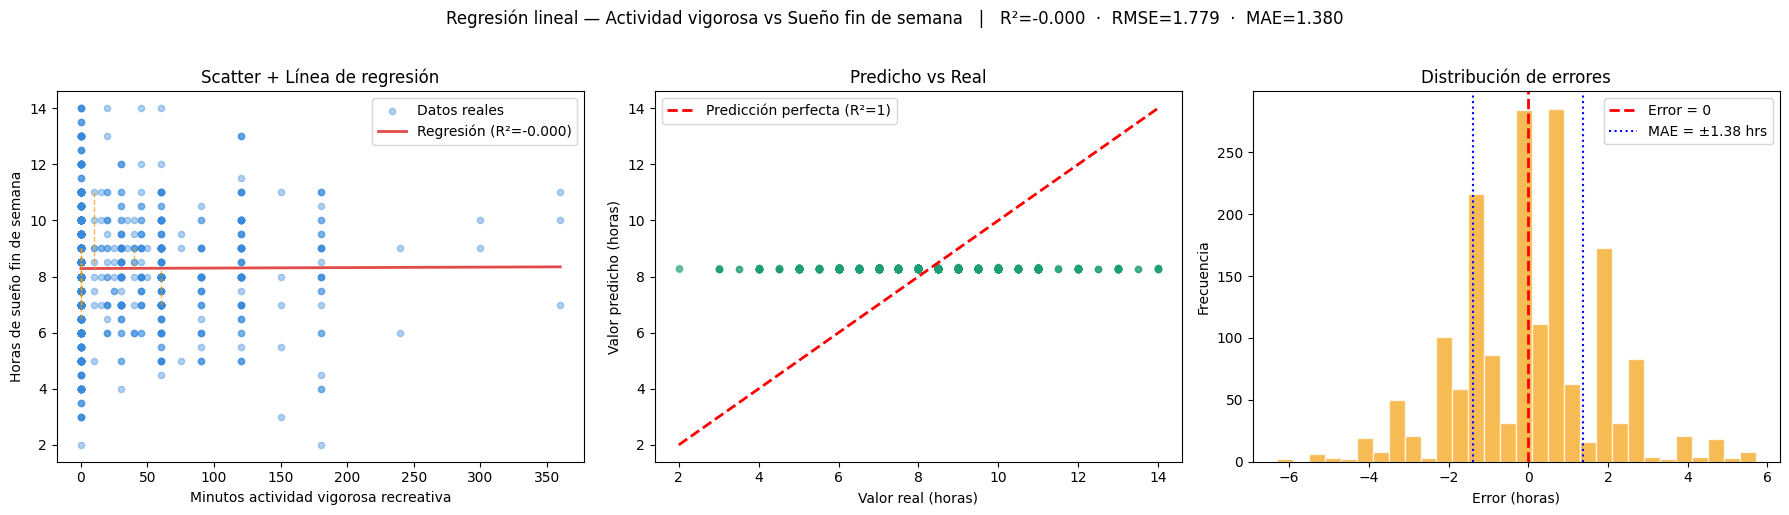

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Preparar datos ───────────────────────────────────────────────
df_lr = df[["vigorous_rec_min", "sleep_weekend_hrs"]].dropna()

X = df_lr[["vigorous_rec_min"]]
y = df_lr["sleep_weekend_hrs"]

# ── Train/Test split ─────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Entrenar ─────────────────────────────────────────────────────
modelo = LinearRegression()
modelo.fit(X_tr, y_tr)
y_pred = modelo.predict(X_te)

# ── Métricas ─────────────────────────────────────────────────────
r2   = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mae  = mean_absolute_error(y_te, y_pred)

print(f"R²:         {r2:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"MAE:        {mae:.4f}")
print(f"Pendiente:  {modelo.coef_[0]:.6f}")
print(f"Intercepto: {modelo.intercept_:.4f}")

# ── Gráficos ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Scatter + línea de regresión + residuos
axes[0].scatter(X_te, y_te, alpha=0.4, color="#378ADD", s=20, label="Datos reales")
x_line = np.linspace(X_te.values.min(), X_te.values.max(), 100)
y_line = modelo.predict(x_line.reshape(-1, 1))
axes[0].plot(x_line, y_line, color="#E24B4A", linewidth=2,
             label=f"Regresión (R²={r2:.3f})")
# Residuos (flechas amarillas cada ~8 puntos)
X_te_arr = X_te.values.flatten()
y_te_arr  = y_te.values
step = max(1, len(X_te_arr) // 8)
for j in range(0, len(X_te_arr), step):
    x_val  = X_te_arr[j]
    y_real = y_te_arr[j]
    y_hat  = modelo.predict([[x_val]])[0]
    axes[0].plot([x_val, x_val], [y_real, y_hat],
                 color="#F59E0B", linewidth=1, linestyle="--", alpha=0.7)
axes[0].set_xlabel("Minutos actividad vigorosa recreativa")
axes[0].set_ylabel("Horas de sueño fin de semana")
axes[0].set_title("Scatter + Línea de regresión")
axes[0].legend()

# Gráfico 2: Predicho vs Real
axes[1].scatter(y_te, y_pred, alpha=0.4, color="#1D9E75", s=20)
lim = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
axes[1].plot(lim, lim, "r--", lw=2, label="Predicción perfecta (R²=1)")
axes[1].set_xlabel("Valor real (horas)")
axes[1].set_ylabel("Valor predicho (horas)")
axes[1].set_title("Predicho vs Real")
axes[1].legend()

# Gráfico 3: Distribución de residuos
residuos = y_te_arr - y_pred
axes[2].hist(residuos, bins=30, color="#F59E0B", alpha=0.7, edgecolor="white")
axes[2].axvline(x=0,    color="red",  linestyle="--", linewidth=2,
                label="Error = 0")
axes[2].axvline(x=mae,  color="blue", linestyle=":",  linewidth=1.5,
                label=f"MAE = ±{mae:.2f} hrs")
axes[2].axvline(x=-mae, color="blue", linestyle=":",  linewidth=1.5)
axes[2].set_xlabel("Error (horas)")
axes[2].set_ylabel("Frecuencia")
axes[2].set_title("Distribución de errores")
axes[2].legend()

plt.suptitle(
    f"Regresión lineal — Actividad vigorosa vs Sueño fin de semana   |   "
    f"R²={r2:.3f}  ·  RMSE={rmse:.3f}  ·  MAE={mae:.3f}",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

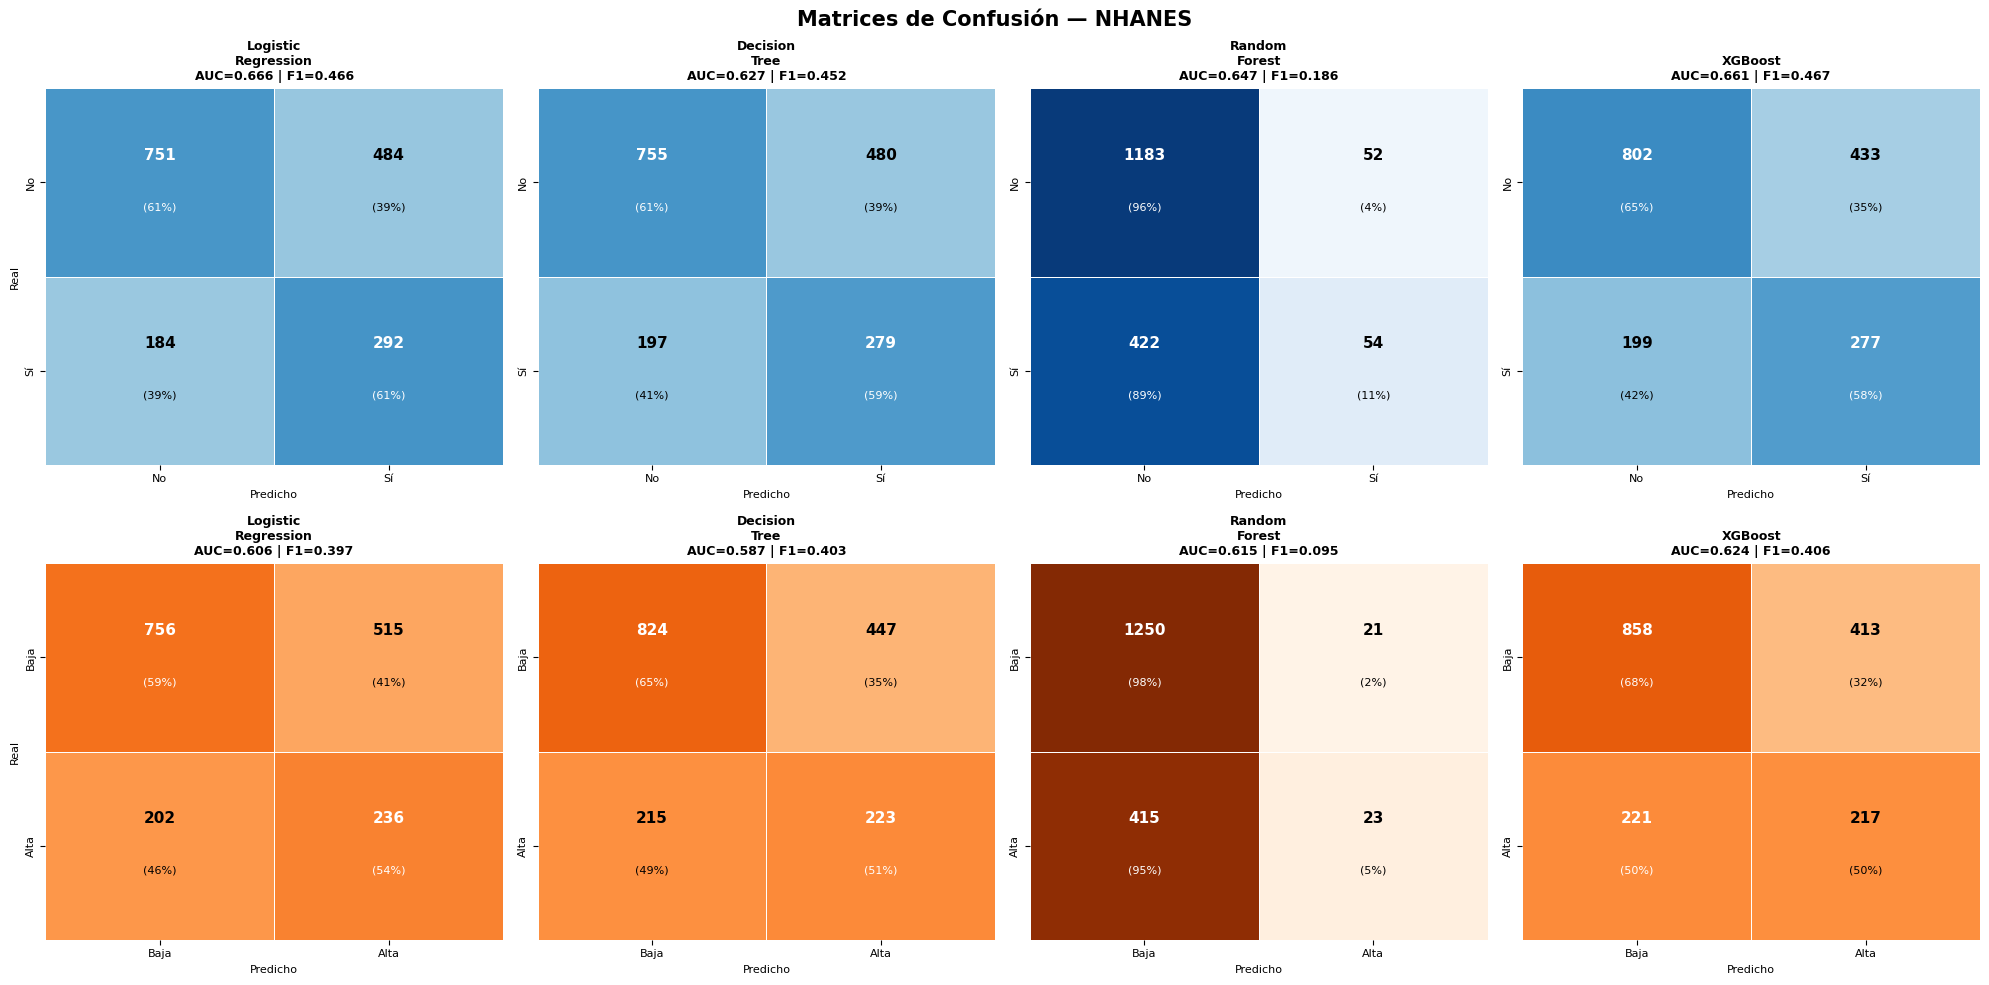

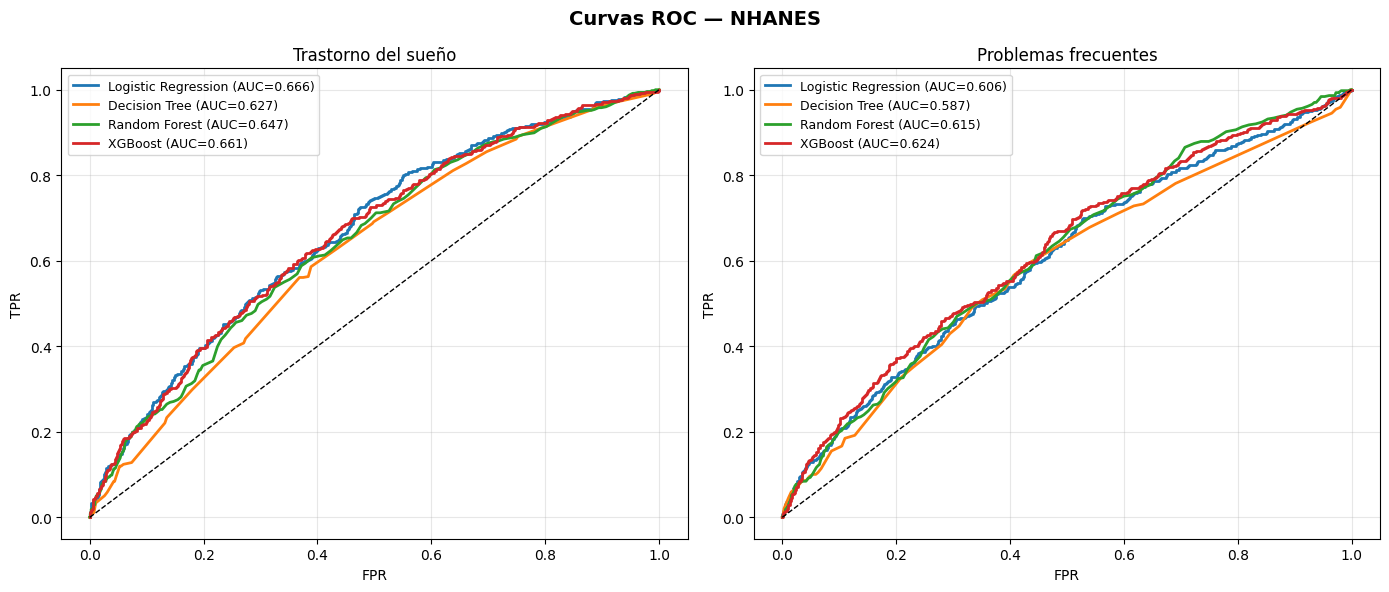

✅ Matrices y curvas ROC generadas


In [18]:
# ════════════════════════════════════════════════════════════════
# CELDA 3a — Matrices de confusión + curvas ROC
# ════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             roc_curve, average_precision_score,
                             precision_recall_curve, f1_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_clf = df.copy()
df_clf["gender"]    = df_clf["gender"].map({"Male": 0, "Female": 1})
df_clf["ethnicity"] = LabelEncoder().fit_transform(df_clf["ethnicity"].astype(str))

# told_sleep_disorder ya está en 0/1 desde celda 18
df_clf["told_sleep_disorder"] = df_clf["told_sleep_disorder"].map(
    {1.0: 1, 2.0: 0, 1: 1, 0: 0}).astype("Int64")

df_clf["target_trouble"] = df_clf["sleep_trouble_freq"].apply(
    lambda x: 1 if x >= 4 else (0 if pd.notna(x) else np.nan)
).astype("Int64")

BASE_FEATURES = [
    "age", "gender", "ethnicity",
    "weight_kg", "height_cm", "bmi", "waist_cm",
    "vigorous_work", "moderate_work",
    "vigorous_work_min", "vigorous_rec", "vigorous_rec_min",
    "resting_pulse", "sleep_weekday_hrs", "sleep_weekend_hrs",
]

targets = {
    "Trastorno del sueño": {"col": "told_sleep_disorder",
                             "labels": ["No","Sí"], "color": "Blues"},
    "Problemas frecuentes": {"col": "target_trouble",
                              "labels": ["Baja","Alta"], "color": "Oranges"},
}

def make_models(spw):
    return {
        "Logistic\nRegression": LogisticRegression(max_iter=1000,
                                class_weight="balanced", random_state=42),
        "Decision\nTree":       DecisionTreeClassifier(max_depth=6,
                                class_weight="balanced", random_state=42),
        "Random\nForest":       RandomForestClassifier(n_estimators=300,
                                class_weight="balanced", random_state=42, n_jobs=-1),
        "XGBoost":              XGBClassifier(n_estimators=300, learning_rate=0.05,
                                max_depth=4, scale_pos_weight=spw,
                                eval_metric="logloss", random_state=42, n_jobs=-1),
    }

# ── Matrices de confusión ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Matrices de Confusión — NHANES", fontsize=15, fontweight="bold")

roc_data = {}   # guardar para curvas ROC

for row_idx, (tname, cfg) in enumerate(targets.items()):
    data  = df_clf[BASE_FEATURES + [cfg["col"]]].dropna()
    X     = StandardScaler().fit_transform(data[BASE_FEATURES].values)
    y     = data[cfg["col"]].values.astype(int)
    neg, pos = (y==0).sum(), (y==1).sum()
    modelos  = make_models(neg/pos)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    roc_data[tname] = {"y_te": y_te, "probs": {}}

    for col_idx, (mname, modelo) in enumerate(modelos.items()):
        ax = axes[row_idx, col_idx]
        modelo.fit(X_tr, y_tr)
        y_prob = modelo.predict_proba(X_te)[:, 1]
        y_pred = modelo.predict(X_te)

        roc_data[tname]["probs"][mname] = y_prob

        cm      = confusion_matrix(y_te, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        auc     = roc_auc_score(y_te, y_prob)
        f1      = f1_score(y_te, y_pred, zero_division=0)

        sns.heatmap(cm_norm, annot=False, cmap=cfg["color"], ax=ax,
                    xticklabels=cfg["labels"], yticklabels=cfg["labels"],
                    vmin=0, vmax=1, linewidths=0.5, cbar=False)

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                pct   = cm_norm[i, j]
                color = "white" if pct > 0.5 else "black"
                ax.text(j+0.5, i+0.38, f"{cm[i,j]}", ha="center",
                        fontsize=11, fontweight="bold", color=color)
                ax.text(j+0.5, i+0.65, f"({pct:.0%})", ha="center",
                        fontsize=8, color=color)

        ax.set_title(f"{mname}\nAUC={auc:.3f} | F1={f1:.3f}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("Predicho", fontsize=8)
        ax.set_ylabel("Real" if col_idx == 0 else "", fontsize=8)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# ── Curvas ROC ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Curvas ROC — NHANES", fontsize=14, fontweight="bold")

for ax, (tname, rdata) in zip(axes, roc_data.items()):
    for mname, y_prob in rdata["probs"].items():
        fpr, tpr, _ = roc_curve(rdata["y_te"], y_prob)
        auc = roc_auc_score(rdata["y_te"], y_prob)
        ax.plot(fpr, tpr, lw=2,
                label=f"{mname.replace(chr(10),' ')} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set(title=tname, xlabel="FPR", ylabel="TPR")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ Matrices y curvas ROC generadas")

In [24]:
# ════════════════════════════════════════════════════════════════
# CELDA 3b — Evaluación final con mejores hiperparámetros
# (correr DESPUÉS del GridSearchCV)
# ════════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("Evaluación final con mejores modelos encontrados por GridSearchCV")
print("="*60)

# ── Modelo 1: LR con C=0.01, l2 → told_sleep_disorder ───────────
data1 = df_clf[BASE_FEATURES + ["told_sleep_disorder"]].dropna()
X1 = StandardScaler().fit_transform(data1[BASE_FEATURES].values)
y1 = data1["told_sleep_disorder"].values.astype(int)

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1)

best_lr = LogisticRegression(C=0.01, penalty="l2", solver="liblinear",
                              class_weight="balanced", max_iter=2000, random_state=42)
best_lr.fit(X_tr1, y_tr1)
y_prob1 = best_lr.predict_proba(X_te1)[:, 1]

# Umbral óptimo por F1
thresholds = np.linspace(0.1, 0.9, 100)
f1s = [f1_score(y_te1, (y_prob1 >= t).astype(int), zero_division=0)
       for t in thresholds]
best_thr1 = thresholds[np.argmax(f1s)]
y_pred1   = (y_prob1 >= best_thr1).astype(int)

print(f"\n🏆 Logistic Regression → Trastorno del sueño")
print(f"   AUC={roc_auc_score(y_te1, y_prob1):.4f} | Umbral óptimo={best_thr1:.2f}")
print(classification_report(y_te1, y_pred1, target_names=["No","Sí"]))

# Coeficientes LR
coef = pd.Series(np.abs(best_lr.coef_[0]), index=BASE_FEATURES).sort_values()
coef.tail(12).plot(kind="barh", ax=axes[1], color="#378ADD")
axes[1].set_title("Coeficientes — Logistic Regression (Trastorno del sueño)")
axes[1].set_xlabel("|Coeficiente|")

plt.tight_layout()
plt.show()
print("✅ Evaluación final completa")

Evaluación final con mejores modelos encontrados por GridSearchCV

🏆 Logistic Regression → Trastorno del sueño
   AUC=0.6648 | Umbral óptimo=0.43
              precision    recall  f1-score   support

          No       0.85      0.44      0.58      1235
          Sí       0.36      0.80      0.49       476

    accuracy                           0.54      1711
   macro avg       0.60      0.62      0.54      1711
weighted avg       0.71      0.54      0.56      1711



<Figure size 640x480 with 0 Axes>

✅ Evaluación final completa


In [23]:
df_clf.head()

,age,gender,ethnicity,weight_kg,height_cm,bmi,waist_cm,vigorous_work,moderate_work,vigorous_work_min,vigorous_rec,vigorous_rec_min,sleep_weekday_hrs,sleep_weekend_hrs,told_sleep_disorder,sleep_trouble_freq,resting_pulse,target_trouble
0,29.0,1,1,97.1,160.2,37.8,117.9,2.0,2.0,0.0,1.0,60.0,7.5,8.0,0,0.0,68.0,0
1,49.0,0,3,98.8,182.3,29.7,120.4,2.0,1.0,0.0,2.0,0.0,10.0,13.0,1,4.0,73.0,1
2,36.0,0,3,74.3,184.2,21.9,86.8,1.0,2.0,240.0,2.0,0.0,6.5,8.0,1,3.0,71.0,0
3,68.0,0,5,103.7,185.3,30.2,109.6,1.0,1.0,480.0,2.0,0.0,9.5,9.5,0,0.0,68.0,0
4,76.0,0,3,83.3,177.1,26.6,99.1,2.0,2.0,0.0,2.0,0.0,7.0,8.0,1,4.0,55.0,1


told_sleep_disorder raw counts: {2.0: 6176, 1.0: 2380, nan: 6}
told_sleep_disorder raw unique: [np.float64(1.0), np.float64(2.0)]
after filter valid target rows: (8556, 17)
after dropna shape: (8541, 17)
after dropna target counts: {0: 6166, 1: 2375}
Dataset final: (8541, 17)
Target: {0: 6166, 1: 2375}

Entrenando Regresión Logística...
Coeficientes: [[0.31059026748303364, 0.19227738804170427, 0.20363573585788713, 0.305102552958555, -0.03723363029831535, -0.1434928132453683, 0.15926898452826854, 0.07168349161208158, 0.02878491352367881, -0.077165767950829, 0.032458459284494416, -0.14305371846204837, 0.03436555349399492, -0.18195523527014054, 0.5018076119912876, 0.021324557600626556]]
Intercepto: [-0.1399690508310846]
Medias del scaler: [48.96370023419204, 0.5165398126463701, 2.3425058548009368, 83.20007318501169, 166.72934718969555, 29.835055620608895, 100.264212529274, 0.25526932084309134, 0.44072014051522246, 52.67666861826698, 0.2549765807962529, 19.293179156908664, 7.60531323185011

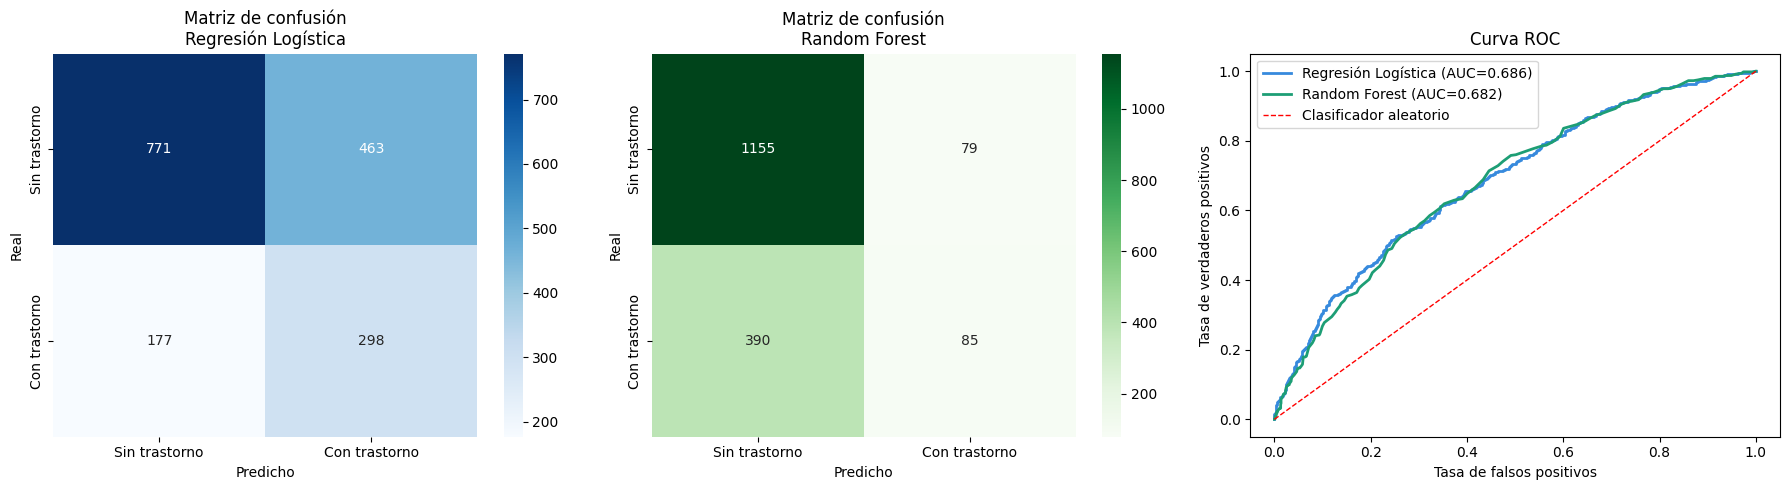

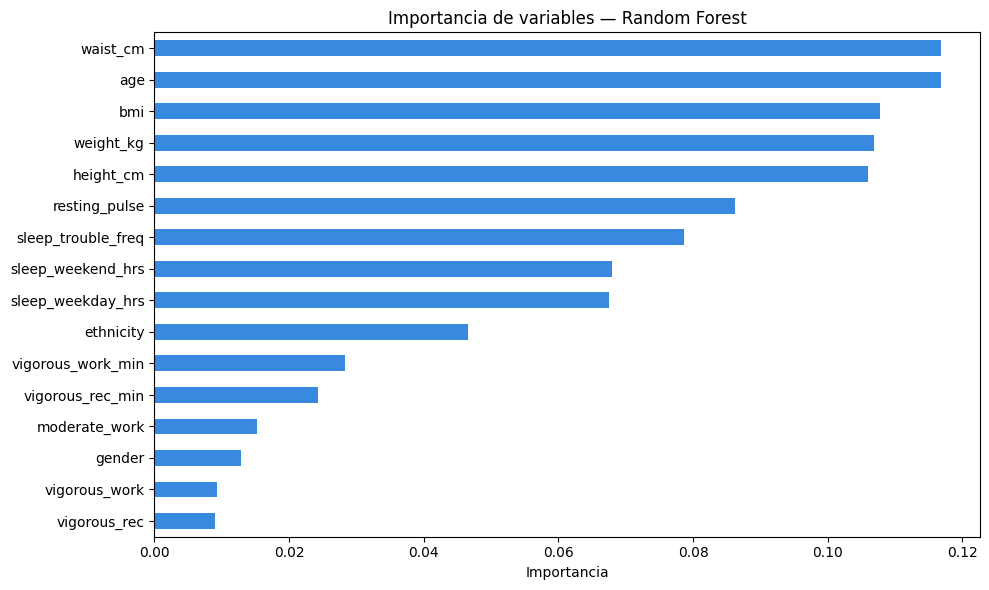


✅ Modelo guardado: vigiax_model.pkl
✅ Scaler guardado: vigiax_scaler.pkl
✅ Encoder guardado: vigiax_encoder.pkl
✅ Features guardados: vigiax_features.pkl


In [25]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preparar copia limpia para el modelo ─────────────────────────
df_model = df.copy()
print("told_sleep_disorder raw counts:", df_model["told_sleep_disorder"].value_counts(dropna=False).to_dict())
print("told_sleep_disorder raw unique:", sorted(df_model["told_sleep_disorder"].dropna().unique()))
df_model = df_model[df_model["told_sleep_disorder"].isin([1.0, 2.0])]
print("after filter valid target rows:", df_model.shape)

# Convertir target: 1=Con trastorno, 0=Sin trastorno
df_model["told_sleep_disorder"] = df_model["told_sleep_disorder"].map({1.0: 1, 2.0: 0, 1: 1, 2: 0})

# Convertir binarias de actividad
for col in ["vigorous_work", "moderate_work", "vigorous_rec"]:
    df_model[col] = df_model[col].map({1.0: 1, 2.0: 0})

# Encodear género
df_model["gender"] = df_model["gender"].map({"Male": 0, "Female": 1})

# Encodear etnia con LabelEncoder y guardar el encoder
le = LabelEncoder()
df_model["ethnicity"] = le.fit_transform(df_model["ethnicity"].astype(str))

# Dropear nulos restantes
df_model = df_model.dropna().reset_index(drop=True)
print("after dropna shape:", df_model.shape)
print("after dropna target counts:", df_model["told_sleep_disorder"].value_counts(dropna=False).to_dict())
if df_model["told_sleep_disorder"].nunique(dropna=True) < 2:
    raise ValueError("No hay al menos dos clases en told_sleep_disorder después de dropna. Revisa la limpieza del dataset.")

print(f"Dataset final: {df_model.shape}")
print(f"Target: {df_model['told_sleep_disorder'].value_counts().to_dict()}")

# ── Features y target ────────────────────────────────────────────
feature_cols = [c for c in df_model.columns if c != "told_sleep_disorder"]
X = df_model[feature_cols]
y = df_model["told_sleep_disorder"]

# ── Train/Test split estratificado ───────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Escalar ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

# ── Entrenar modelos ─────────────────────────────────────────────
print("\nEntrenando Regresión Logística...")
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_tr_sc, y_tr)

# Imprimir los valores para actualizar predict.ts
print("Coeficientes:", lr.coef_.tolist())
print("Intercepto:", lr.intercept_.tolist())
print("Medias del scaler:", scaler.mean_.tolist())
print("Escalas del scaler:", scaler.scale_.tolist())
print("Clases del encoder:", le.classes_.tolist())

print("Entrenando Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)

# ── Métricas ─────────────────────────────────────────────────────
y_pred_lr = lr.predict(X_te_sc)
y_pred_rf = rf.predict(X_te)
y_prob_lr = lr.predict_proba(X_te_sc)[:, 1]
y_prob_rf = rf.predict_proba(X_te)[:, 1]

print("\n========== Regresión Logística ==========")
print(classification_report(y_te, y_pred_lr,
      target_names=["Sin trastorno", "Con trastorno"]))
print(f"ROC-AUC: {roc_auc_score(y_te, y_prob_lr):.4f}")

print("\n========== Random Forest =================")
print(classification_report(y_te, y_pred_rf,
      target_names=["Sin trastorno", "Con trastorno"]))
print(f"ROC-AUC: {roc_auc_score(y_te, y_prob_rf):.4f}")

# ── Gráficos ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión LR
cm_lr = confusion_matrix(y_te, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Sin trastorno", "Con trastorno"],
            yticklabels=["Sin trastorno", "Con trastorno"])
axes[0].set_title("Matriz de confusión\nRegresión Logística")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

# Matriz de confusión RF
cm_rf = confusion_matrix(y_te, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Sin trastorno", "Con trastorno"],
            yticklabels=["Sin trastorno", "Con trastorno"])
axes[1].set_title("Matriz de confusión\nRandom Forest")
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_te, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_te, y_prob_rf)
auc_lr = roc_auc_score(y_te, y_prob_lr)
auc_rf = roc_auc_score(y_te, y_prob_rf)
axes[2].plot(fpr_lr, tpr_lr, color="#378ADD", lw=2,
             label=f"Regresión Logística (AUC={auc_lr:.3f})")
axes[2].plot(fpr_rf, tpr_rf, color="#1D9E75", lw=2,
             label=f"Random Forest (AUC={auc_rf:.3f})")
axes[2].plot([0,1],[0,1], "r--", lw=1, label="Clasificador aleatorio")
axes[2].set_xlabel("Tasa de falsos positivos")
axes[2].set_ylabel("Tasa de verdaderos positivos")
axes[2].set_title("Curva ROC")
axes[2].legend()

plt.tight_layout()
plt.show()

# ── Feature importance (Random Forest) ───────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="#378ADD")
plt.title("Importancia de variables — Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

# ── Guardar modelo, scaler y encoder ────────────────────────────
joblib.dump(rf,     "vigiax_model.pkl")
joblib.dump(scaler, "vigiax_scaler.pkl")
joblib.dump(le,     "vigiax_encoder.pkl")
joblib.dump(feature_cols, "vigiax_features.pkl")

print("\n✅ Modelo guardado: vigiax_model.pkl")
print("✅ Scaler guardado: vigiax_scaler.pkl")
print("✅ Encoder guardado: vigiax_encoder.pkl")
print("✅ Features guardados: vigiax_features.pkl")

In [21]:
print(BASE_FEATURES)

['age', 'gender', 'ethnicity', 'weight_kg', 'height_cm', 'bmi', 'waist_cm', 'vigorous_work', 'moderate_work', 'vigorous_work_min', 'vigorous_rec', 'vigorous_rec_min', 'resting_pulse', 'sleep_weekday_hrs', 'sleep_weekend_hrs']


In [ ]:
joblib.dump(lr,     "vigiax_lr_model.pkl")
print("✅ Modelo LR guardado: vigiax_lr_model.pkl")

✅ Modelo LR guardado: vigiax_lr_model.pkl


In [ ]:
from google.colab import files
files.download("vigiax_lr_model.pkl")
files.download("vigiax_scaler.pkl")
files.download("vigiax_encoder.pkl")
files.download("vigiax_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import numpy as np

# Carga los archivos guardados
model = joblib.load("vigiax_lr_model.pkl")
scaler = joblib.load("vigiax_scaler.pkl")
encoder = joblib.load("vigiax_encoder.pkl")

# Imprime los valores que necesito
print("Coeficientes (model.coef_):", model.coef_.tolist())
print("Intercepto (model.intercept_):", model.intercept_.tolist())
print("Medias del scaler (scaler.mean_):", scaler.mean_.tolist())
print("Escalas del scaler (scaler.scale_):", scaler.scale_.tolist())
print("Clases del encoder (encoder.classes_):", encoder.classes_.tolist())

Coeficientes (model.coef_): [[0.31059026748303364, 0.19227738804170427, 0.20363573585788713, 0.305102552958555, -0.03723363029831535, -0.1434928132453683, 0.15926898452826854, 0.07168349161208158, 0.02878491352367881, -0.077165767950829, 0.032458459284494416, -0.14305371846204837, 0.03436555349399492, -0.18195523527014054, 0.5018076119912876, 0.021324557600626556]]
Intercepto (model.intercept_): [-0.1399690508310846]
Medias del scaler (scaler.mean_): [48.96370023419204, 0.5165398126463701, 2.3425058548009368, 83.20007318501169, 166.72934718969555, 29.835055620608895, 100.264212529274, 0.25526932084309134, 0.44072014051522246, 52.67666861826698, 0.2549765807962529, 19.293179156908664, 7.6053132318501175, 8.288202576112413, 2.56806206088993, 69.10362997658079]
Escalas del scaler (scaler.scale_): [18.314689165685213, 0.49972635971861934, 1.293478977753709, 23.018765541012723, 10.068863781024035, 7.502359642260852, 16.978585751364093, 0.4360124937193867, 0.49647346178770224, 121.6592935946

In [ ]:
# Después de model.fit(X_train, y_train)
print("Coeficientes:", model.coef_.tolist())
print("Intercepto:", model.intercept_.tolist())
print("Medias del scaler:", scaler.mean_.tolist())
print("Escalas del scaler:", scaler.scale_.tolist())
print("Clases del encoder:", encoder.classes_.tolist())

Coeficientes: [[0.31059026748303364, 0.19227738804170427, 0.20363573585788713, 0.305102552958555, -0.03723363029831535, -0.1434928132453683, 0.15926898452826854, 0.07168349161208158, 0.02878491352367881, -0.077165767950829, 0.032458459284494416, -0.14305371846204837, 0.03436555349399492, -0.18195523527014054, 0.5018076119912876, 0.021324557600626556]]
Intercepto: [-0.1399690508310846]
Medias del scaler: [48.96370023419204, 0.5165398126463701, 2.3425058548009368, 83.20007318501169, 166.72934718969555, 29.835055620608895, 100.264212529274, 0.25526932084309134, 0.44072014051522246, 52.67666861826698, 0.2549765807962529, 19.293179156908664, 7.6053132318501175, 8.288202576112413, 2.56806206088993, 69.10362997658079]
Escalas del scaler: [18.314689165685213, 0.49972635971861934, 1.293478977753709, 23.018765541012723, 10.068863781024035, 7.502359642260852, 16.978585751364093, 0.4360124937193867, 0.49647346178770224, 121.65929359461903, 0.4358480515520344, 42.34441448707984, 1.6597891577715018,